# Import Library 

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Read  Csv

In [33]:
data = pd.read_csv('dirty_cafe_sales.csv')
print(data)

     Transaction ID      Item Quantity Price Per Unit Total Spent  \
0       TXN_1961373    Coffee        2            2.0         4.0   
1       TXN_4977031      Cake        4            3.0        12.0   
2       TXN_4271903    Cookie        4            1.0       ERROR   
3       TXN_7034554     Salad        2            5.0        10.0   
4       TXN_3160411    Coffee        2            2.0         4.0   
...             ...       ...      ...            ...         ...   
9995    TXN_7672686    Coffee        2            2.0         4.0   
9996    TXN_9659401       NaN        3            NaN         3.0   
9997    TXN_5255387    Coffee        4            2.0         8.0   
9998    TXN_7695629    Cookie        3            NaN         3.0   
9999    TXN_6170729  Sandwich        3            4.0        12.0   

      Payment Method  Location Transaction Date  
0        Credit Card  Takeaway       2023-09-08  
1               Cash  In-store       2023-05-16  
2        Credit Card 

# inisialisasi variabel dataset numerik

In [34]:
datasetQty = data['Quantity']
datasetPrice =  data['Price Per Unit']
datasetTotal = data['Total Spent']

print('kolom quantity:')
print(datasetQty)

print('kolom price per unit:')
print(datasetPrice)

print('kolom total spent:')
print(datasetTotal)

kolom quantity:
0       2
1       4
2       4
3       2
4       2
       ..
9995    2
9996    3
9997    4
9998    3
9999    3
Name: Quantity, Length: 10000, dtype: object
kolom price per unit:
0       2.0
1       3.0
2       1.0
3       5.0
4       2.0
       ... 
9995    2.0
9996    NaN
9997    2.0
9998    NaN
9999    4.0
Name: Price Per Unit, Length: 10000, dtype: object
kolom total spent:
0         4.0
1        12.0
2       ERROR
3        10.0
4         4.0
        ...  
9995      4.0
9996      3.0
9997      8.0
9998      3.0
9999     12.0
Name: Total Spent, Length: 10000, dtype: object


# check missing value

In [35]:
dataset = data.isnull().sum()
if dataset.any():
    print("Terdapat nilai yang hilang dalam dataset.")
else:    
    print("Tidak terdapat nilai yang hilang dalam dataset.")
    print(dataset)

Terdapat nilai yang hilang dalam dataset.


# Check duplicate dataset

In [38]:
dataDuplicate = dataset[dataset.duplicated()]
print("Data yang duplikat:")
print(dataDuplicate)
print('Jumlah duplicate', dataset.duplicated().sum())

Data yang duplikat:
Series([], dtype: int64)
Jumlah duplicate 0


# calculating total duplicate

In [44]:
totalDataset = dataset.duplicated()

totalDataset = pd.DataFrame(datasetPrice + datasetQty + datasetTotal)
print(totalDataset)

              0
0       2.024.0
1      3.0412.0
2     1.04ERROR
3      5.0210.0
4       2.024.0
...         ...
9995    2.024.0
9996        NaN
9997    2.048.0
9998        NaN
9999   4.0312.0

[10000 rows x 1 columns]


# Handling Outlier Detection

In [42]:
print(totalDataset.describe())

          0
count     0
unique    0
top     NaN
freq    NaN


In [10]:
Q1 = dataset.quantile(0.25)
Q3 = dataset.quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

dataset = dataset.clip(lower, upper)
print("Dataset setelah mengatasi outlier:")


print(dataset)
print(dataset.value_counts())

Dataset setelah mengatasi outlier:
Transaction ID         0.000
Item                 333.000
Quantity             138.000
Price Per Unit       179.000
Total Spent          173.000
Payment Method      2005.625
Location            2005.625
Transaction Date     159.000
dtype: float64
2005.625    2
0.000       1
333.000     1
138.000     1
179.000     1
173.000     1
159.000     1
Name: count, dtype: int64


In [13]:

import matplotlib.pyplot as plt
%matplotlib inline

numeric_cols = totalDataset.select_dtypes(include=['int64', 'float64']).columns
numeric_cols = numeric_cols.drop('Transaction ID', errors='ignore')

for col in numeric_cols:
    before_data = totalDataset[col].copy()

    Q1 = before_data.quantile(0.25)
    Q3 = before_data.quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    after_data = before_data.clip(lower, upper)

    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    plt.boxplot(before_data.dropna())
    plt.title(f"Before: {col}")

    plt.subplot(1,2,2)
    plt.boxplot(after_data.dropna())
    plt.title(f"After: {col}")

    plt.tight_layout()
    plt.show()

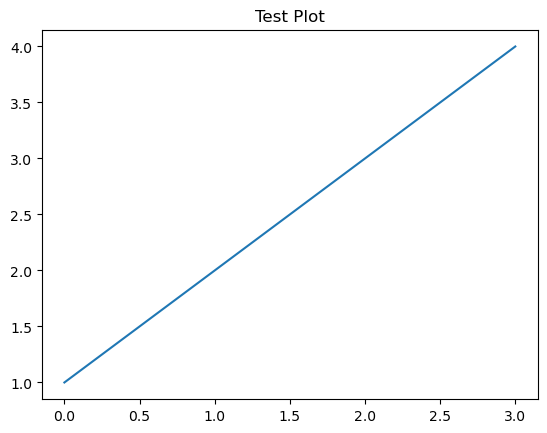

In [14]:
import matplotlib.pyplot as plt

plt.plot([1,2,3,4])
plt.title("Test Plot")
plt.show()

In [20]:
print(data.head())
print(data.info())
print(data.describe())
print(data.dtypes)

  Transaction ID    Item Quantity Price Per Unit Total Spent  Payment Method  \
0    TXN_1961373  Coffee        2            2.0         4.0     Credit Card   
1    TXN_4977031    Cake        4            3.0        12.0            Cash   
2    TXN_4271903  Cookie        4            1.0       ERROR     Credit Card   
3    TXN_7034554   Salad        2            5.0        10.0         UNKNOWN   
4    TXN_3160411  Coffee        2            2.0         4.0  Digital Wallet   

   Location Transaction Date  
0  Takeaway       2023-09-08  
1  In-store       2023-05-16  
2  In-store       2023-07-19  
3   UNKNOWN       2023-04-27  
4  In-store       2023-06-11  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    10000 non-null  object
 1   Item              9667 non-null   object
 2   Quantity          9862 non-null   obj